In [2]:
from datatools import get_price, get_basic
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.signal import argrelextrema

In [3]:
df = get_price(codes = ['300274.SZ'], start_date='2011-11-02', end_date='2025-12-31', fields=['close'], fq='post')

In [4]:
high_idx = argrelextrema(df['close'].values, np.greater_equal, order=126)[0]
highs = df.iloc[high_idx]

In [5]:
# 计算相邻高点间隔
highs['prev_date'] = highs['trade_date'].shift(1)
highs['interval_days'] = (highs['trade_date'] - highs['prev_date']).dt.days
highs['interval_years'] = highs['interval_days'] / 252

In [6]:
mean_interval = highs['interval_years'].mean()
median_interval = highs['interval_years'].median()

=== 显著高点验证结果（局部峰值，非历史新高） ===
总共识别出 9 个显著高点
平均间隔：2.53 年
中位数间隔：2.58 年
间隔标准差：0.96 年

各次高点间隔（年）：
     trade_date    close  interval_years
17   2011-11-25    36.63             NaN
540  2014-02-10    73.24            3.21
851  2015-06-03   187.29            1.90
1438 2017-11-13   144.57            3.55
1787 2019-04-19    88.56            2.07
2398 2021-10-27  1170.51            3.66
2600 2022-08-23   982.79            1.19
3111 2024-10-08  1143.87            3.08
3375 2025-11-06  2017.71            1.56


C:\Users\User\AppData\Local\Temp\ipykernel_15540\3293300866.py:8: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(highs[['trade_date', 'close', 'interval_years']].round(2))


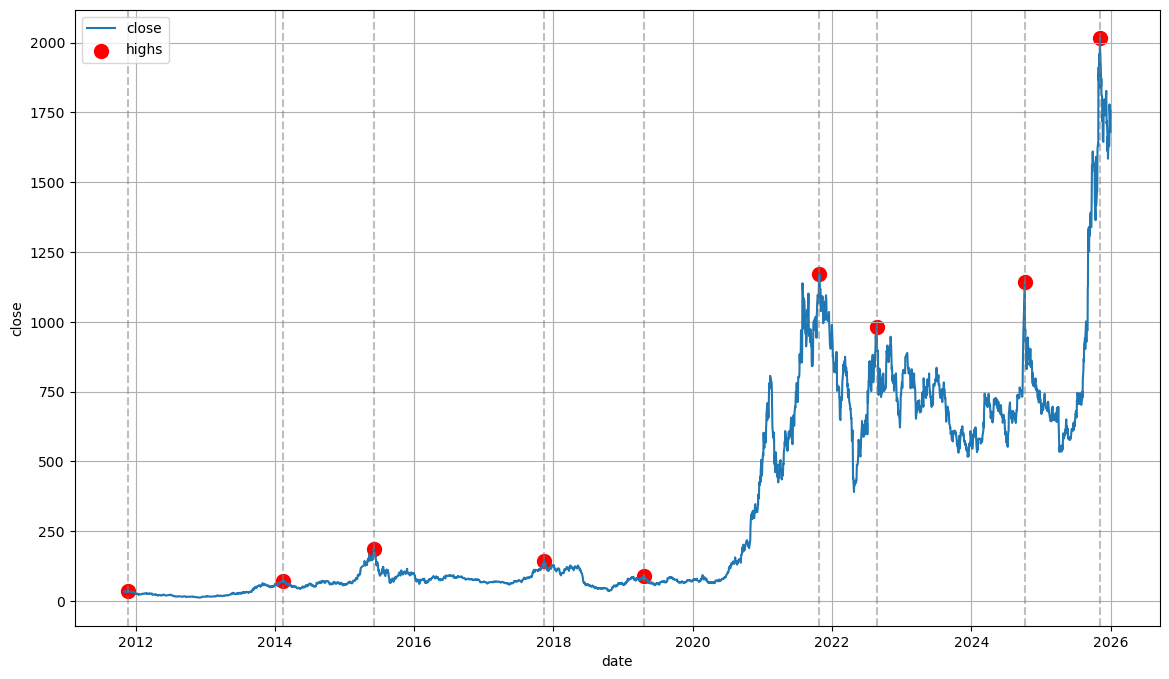

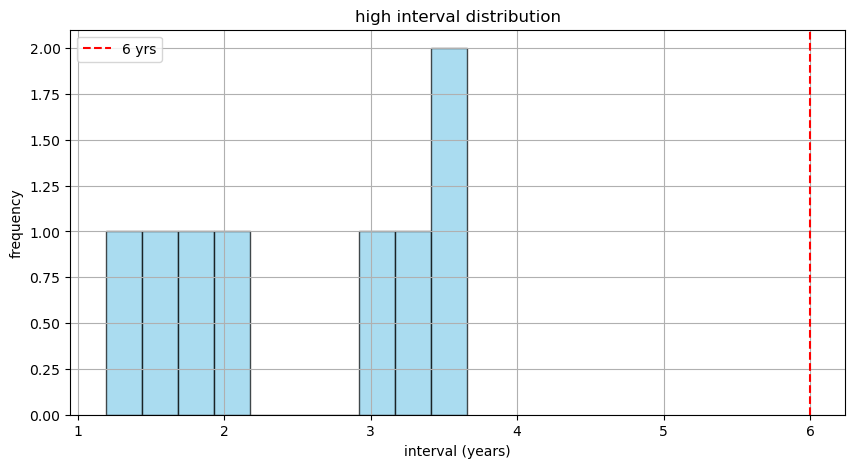

In [7]:
# 统计
print("=== 显著高点验证结果（局部峰值，非历史新高） ===")
print(f"总共识别出 {len(highs)} 个显著高点")
print(f"平均间隔：{mean_interval:.2f} 年")
print(f"中位数间隔：{median_interval:.2f} 年")
print(f"间隔标准差：{highs['interval_years'].std():.2f} 年")
print("\n各次高点间隔（年）：")
print(highs[['trade_date', 'close', 'interval_years']].round(2))

# 可视化
plt.figure(figsize=(14, 8))
plt.plot(df['trade_date'], df['close'], label='close', linewidth=1.5)
plt.scatter(highs['trade_date'], highs['close'], color='red', s=100, label='highs')

# 画6年周期参考线
for i in range(len(highs)):
    plt.axvline(highs['trade_date'].iloc[i], color='gray', linestyle='--', alpha=0.5)


plt.xlabel('date')
plt.ylabel('close')
plt.legend()
plt.grid(True)
plt.show()

# 间隔分布直方图
plt.figure(figsize=(10, 5))
plt.hist(highs['interval_years'], bins=10, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(6, color='red', linestyle='--', label='6 yrs')
plt.title('high interval distribution')
plt.xlabel('interval (years)')
plt.ylabel('frequency')
plt.legend()
plt.grid(True)
plt.show()